# Chi-Square Test for Categorical Feature Selection

**Problem:** You have many categorical (string) columns. Should you encode all of them before training a model?

**Answer:** Not always. Some columns may have no link to your target. They just add noise.

**Solution:** Run a **chi-square test** on each categorical feature vs the target. It tells you which features are worth keeping.

**Dataset:** `loan_applications.csv` (1,200 rows)

| Column | What it is | Values |
|--------|-----------|--------|
| `employment` | Job type | Employed / Self-Employed / Unemployed |
| `education` | Education level | Graduate / Not Graduate |
| `property_area` | Location type | Urban / Rural / Semiurban |
| `loan_status` | Target | 1 = approved, 0 = rejected |

**Key terms we will use:**
- **Contingency table** = count table (how many approved/rejected in each category)
- **Null hypothesis** = feature and target have no connection
- **p-value** = chance of seeing this gap by luck. Low p (< 0.05) = feature is useful

In [7]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## Step 2: Load and Profile the Categorical Columns

First, load the data.

Then check value counts and approval rate for each category.

If approval rate looks very different across categories, the feature may be useful.

This is a quick visual check before the formal test.

In [8]:

df = pd.read_csv("datasets/loan_applications.csv")

categorical_features = ["employment", "education", "property_area"]

print(f"Dataset shape: {df.shape}")
print(f"Overall approval rate: {df['loan_status'].mean():.4f}\n")

for feature in categorical_features:
    print(f"--- {feature} ---")
    print(df[feature].value_counts())
    print()
    approval_by_category = df.groupby(feature)["loan_status"].mean()
    print("Approval rate by category:")
    print(approval_by_category)
    print()

Dataset shape: (1200, 7)
Overall approval rate: 0.6125

--- employment ---
employment
Employed         783
Self-Employed    291
Unemployed       126
Name: count, dtype: int64

Approval rate by category:
employment
Employed         0.661558
Self-Employed    0.642612
Unemployed       0.238095
Name: loan_status, dtype: float64

--- education ---
education
Graduate        797
Not Graduate    403
Name: count, dtype: int64

Approval rate by category:
education
Graduate        0.770389
Not Graduate    0.300248
Name: loan_status, dtype: float64

--- property_area ---
property_area
Urban        455
Rural        420
Semiurban    325
Name: count, dtype: int64

Approval rate by category:
property_area
Rural        0.509524
Semiurban    0.520000
Urban        0.773626
Name: loan_status, dtype: float64



## Step 3: Visualise Approval Rate by Category

Bar charts make the gap easy to see.

Big gap between bars = feature likely has signal.

Similar bar heights = feature may not help.

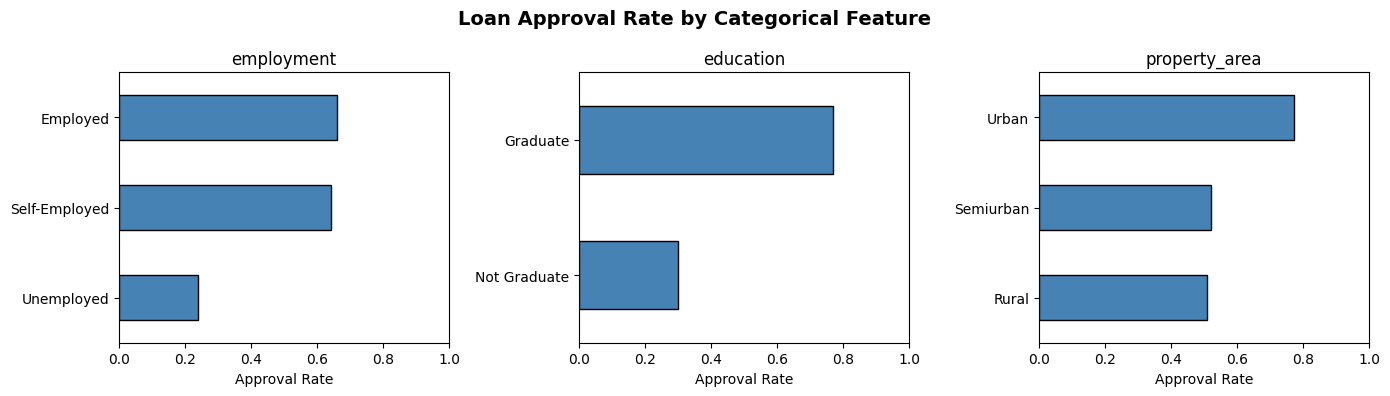

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feature in zip(axes, categorical_features):
    approval_rates = df.groupby(feature)["loan_status"].mean().sort_values(ascending=True)
    approval_rates.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(feature)
    ax.set_xlabel("Approval Rate")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)

fig.suptitle("Loan Approval Rate by Categorical Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4: Build the Contingency Table for Each Feature

A **contingency table** is just a count table.

Rows = feature categories.

Columns = target (0 = rejected, 1 = approved).

Each cell = how many people fall in that combination.

Example: how many Employed people got approved vs rejected.

In [10]:
contingency_tables = {}

for feature in categorical_features:
    table = pd.crosstab(df[feature], df["loan_status"])
    contingency_tables[feature] = table
    print(f"--- Contingency table: {feature} vs loan_status ---")
    print(table)
    print()

--- Contingency table: employment vs loan_status ---
loan_status      0    1
employment             
Employed       265  518
Self-Employed  104  187
Unemployed      96   30

--- Contingency table: education vs loan_status ---
loan_status     0    1
education             
Graduate      183  614
Not Graduate  282  121

--- Contingency table: property_area vs loan_status ---
loan_status      0    1
property_area          
Rural          206  214
Semiurban      156  169
Urban          103  352



## Step 5: Run the Chi-Square Test

**Null hypothesis (H₀):** feature and target are independent. No connection.

**What the test does:** compares observed counts (from table above) vs expected counts (if there was no connection).

**p-value meaning:** if there is really no connection, what is the chance of seeing a gap this big by luck?

- p < 0.05 → significant → keep the feature
- p ≥ 0.05 → not significant → consider dropping the feature

In [11]:
results = []

for feature in categorical_features:
    table = contingency_tables[feature]
    chi2, p_value, dof, expected = chi2_contingency(table)
    results.append(
        {
            "feature": feature,
            "chi2_statistic": chi2,
            "p_value": p_value,
            "degrees_of_freedom": dof,
        }
    )
    print(f"--- {feature} ---")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  p-value:              {p_value:.6f}")
    print(f"  Degrees of freedom:   {dof}")
    print(f"  Significant (p < 0.05): {p_value < 0.05}")
    print()

--- employment ---
  Chi-square statistic: 83.47
  p-value:              0.000000
  Degrees of freedom:   2
  Significant (p < 0.05): True

--- education ---
  Chi-square statistic: 247.29
  p-value:              0.000000
  Degrees of freedom:   1
  Significant (p < 0.05): True

--- property_area ---
  Chi-square statistic: 80.25
  p-value:              0.000000
  Degrees of freedom:   2
  Significant (p < 0.05): True



## Step 6: Build the Significance Summary Table

Sort by chi-square statistic (highest first).

Higher chi-square = stronger connection with the target.

This ranking helps you decide which features matter most.

In [12]:
summary = pd.DataFrame(results)
summary["significant"] = summary["p_value"] < 0.05
summary = summary.sort_values("chi2_statistic", ascending=False).reset_index(drop=True)

summary_display = summary.copy()
summary_display["chi2_statistic"] = summary_display["chi2_statistic"].round(2)
summary_display["p_value"] = summary_display["p_value"].round(6)

print(summary_display.to_string(index=False))

      feature  chi2_statistic  p_value  degrees_of_freedom  significant
    education          247.29      0.0                   1         True
   employment           83.47      0.0                   2         True
property_area           80.25      0.0                   2         True


## Step 7: One Sentence of Reasoning per Feature

**employment** (p ≈ 0, χ² = 83.47): This feature is significant because unemployed people have only 24% approval while employed people have 66%, so I would keep it in the model.

**education** (p ≈ 0, χ² = 247.29): This is the strongest feature because graduates have 77% approval but non-graduates have only 30%, so I would definitely keep it.

**property_area** (p ≈ 0, χ² = 80.25): This feature is significant because urban areas have 77% approval while rural and semiurban are near 51%, so I would keep it but it is less important than education.